In [3]:
import xgi
import numpy as np
import pickle
from itertools import product
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [4]:
# set params for all plots

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = 'Geneva'

# one color for each value of N
cmap = plt.get_cmap('viridis')
colors = cmap(np.linspace(0.85, 0, 4))  # ['black', 'blue', 'green', 'orange']

ttl_size = 16
lgd_size = 12
tick_size = 15
lw = 2
mrksize = 5
bbox_legend =(0.5, 0.002)
rect_tl = [0, 0.06, 1, 0.94]

figsize2x2 = (9, 6.5)
figsize2x3 = (14, 7)
figsize3x3 = (14, 9)
figsize4x3 = (14, 12)
figsize2x4 = (15, 6)
figsize3x4 = (15, 8)
ttl_size4x3 = 21

dpi=150

# Sketch of the model

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2225/2233330355.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


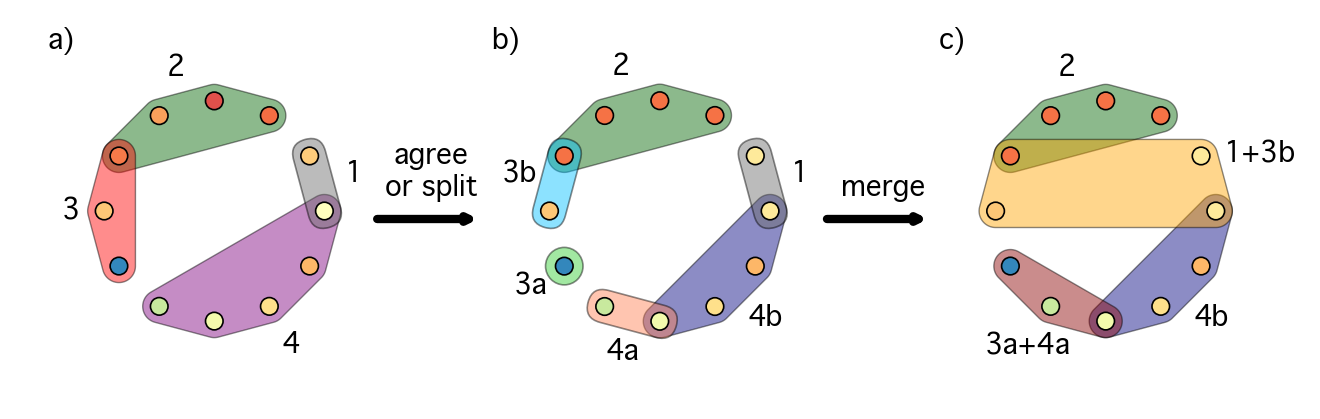

In [4]:
import matplotlib.cm as cm
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch, Circle

# Helper function: push hyperedge label radially outward
def get_outside_label_pos(nodes_pos, center=np.array([0,0]), offset=0.25):
    pts = np.array(nodes_pos)
    centroid = pts.mean(axis=0)
    # vector from center to centroid
    v = centroid - center
    angle = np.arctan2(v[1], v[0])
    # radial placement outside
    r = np.linalg.norm(v) + offset

    return np.array([np.cos(angle)*r, np.sin(angle)*r])

# Function to draw pairwise edges as hulls instead of lines
def draw_dyad_capsule(ax, p0, p1, width=0.10,
                      facecolor='lightgray',
                      edgecolor='black',
                      alpha=0.45,
                      zorder=2):
    """
    Draw a rounded capsule between p0 and p1.
    p0, p1: numpy arrays of shape (2,)
    width: capsule thickness (≈ hyperedge hull thickness)
    """

    node_radius = 0.3
    # vector between nodes
    v = (p1 - p0)
    # extend endpoints beyond node centers
    p0 = p0 - node_radius * v
    p1 = p1 + node_radius * v
    L = np.linalg.norm(p1 - p0)
    v = v / L

    # angle of the dyad
    angle = np.degrees(np.arctan2(v[1], v[0]))

    # capsule lower-left corner (before rotation)
    x = p0[0]
    y = p0[1] - width / 2

    capsule = FancyBboxPatch(
        (x, y),
        L, width,
        boxstyle=f"round,pad=0,rounding_size={width/2}",
        linewidth=1.2,
        facecolor=facecolor,
        edgecolor=edgecolor,
        alpha=alpha,
        zorder=zorder
    )

    # rotate around p0
    t = mpl.transforms.Affine2D().rotate_deg_around(p0[0], p0[1], angle)
    capsule.set_transform(t + ax.transData)

    ax.add_patch(capsule)


# Choose colormap
cmap = plt.get_cmap('Spectral')
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=cmap) 
sm.set_array([])

h_list = [
    xgi.Hypergraph({'1':[0,1], '2':[6,7,8,9], '3':[9,10,11], '4':[0,2,3,4,5]}),
    xgi.Hypergraph({'1':[0,1], '2':[6,7,8,9], '3a':[11], '3b':[9,10], '4b':[0,3,4,5], '4a':[2,3]}),
    xgi.Hypergraph({'1+3b':[0,1,9,10], '2':[6,7,8,9], '3a+4a':[2,3,11], '4b':[0,3,4,5]})
]
op_list = [
    {0:0.5, 1:0.36, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.2, 7:0.14, 8:0.28, 9:0.22, 10:0.35, 11:0.9 },
    {0:0.43, 1:0.43, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.21, 7:0.21, 8:0.21, 9:0.21, 10:0.35, 11:0.9 },
    {0:0.43, 1:0.43, 2:0.65, 3:0.55, 4:0.4, 5:0.32, 6:0.21, 7:0.21, 8:0.21, 9:0.21, 10:0.35, 11:0.9 }
]
he_clrs = [
            ['darkgreen','red','purple'],
            ['darkgreen','navy'],
            ['orange','darkgreen','darkred','navy']
        ]

# Use the same circular layout for all plots
pos = xgi.circular_layout(h_list[0])

fig = plt.figure(figsize=(13,4))
# Wide layout with gaps (wspace controls spacing)
gs = gridspec.GridSpec(1, 3, wspace=0.6, left=0.05, right=0.95)
ax = [fig.add_subplot(gs[i]) for i in range(3)]


for i in range(3):
    h = h_list[i]

    # 1) Draw only hulls / hyperedges (hide nodes inside XGI)
    xgi.draw(h, ax=ax[i], pos=pos, hull=True, radius=0.15,
             dyad_lw=0, alpha=0.45, edge_fc=he_clrs[i], edge_ec='black',
             node_size=0, node_labels=False)   # node_size=0 hides XGI nodes

    # 2) Prepare node ordering and scalar values (use sorted order to be stable)
    nodes_sorted = sorted(h.nodes)                      # stable order
    values = [op_list[i].get(n, 0.0) for n in nodes_sorted]  # fallback 0.0 if missing

    # 3) Draw nodes with scatter so colormap mapping is deterministic
    xy = np.array([pos[n] for n in nodes_sorted])
    ax[i].scatter(xy[:, 0], xy[:, 1],
                  s=160,                # adjust node size (area)
                  c=values,             # pass scalars
                  cmap=cmap, norm=norm, edgecolors='k', linewidths=1.2, zorder=3)

    # 4) Draw node labels (manual, so labels align with nodes_sorted)
    #for n, (x, y) in zip(nodes_sorted, xy):
     #   ax[i].text(x, y, str(n), ha='center', va='center',
      #             fontsize=10, zorder=4)

    # 5) hyperedge labels outside
    for eid, attr in h.edges.items():
        nodes = list(h.edges.members(eid))
        pts = [pos[n] for n in nodes]

        if not eid == '1+3b':
            ofs = 0.13*len(nodes) if len(nodes) > 2 else 0.35
            if len(eid) > 3:
                ofs = 0.5
            out_pos = get_outside_label_pos(pts, center=np.array([0,0]), offset=ofs)
            ax[i].text(out_pos[0], out_pos[1], eid, ha='center', va='center',
                       fontsize=20, fontweight='bold')
        else:
            ax[i].text(1.4, 0.52, eid, ha='center', va='center', fontsize=20, fontweight='bold')

        # draw hyperedges for dyads and isolated node
        dyad_clr = {'1':'dimgray', '3a':'limegreen', '3b':'deepskyblue', '4a':'coral'}
        if len(nodes) == 2:
            p0 = np.array(pos[nodes[0]])
            p1 = np.array(pos[nodes[1]])
            draw_dyad_capsule(ax[i], p0, p1, width=0.3, facecolor=dyad_clr[eid], edgecolor='black', alpha=0.45)
        if len(nodes) == 1:
            u = nodes[0]
            center = np.array(pos[u])
            # draw circle around isolated nodes (hyperedge of size 1)
            circ = Circle(center, radius=0.17, facecolor=dyad_clr[eid], edgecolor='black', linewidth=1.2, alpha=0.45, zorder=1)
            ax[i].add_patch(circ)
            

    ax[i].set_aspect('equal')
    ax[i].axis('off')
    

# Add subplot labels
lbls = ['a)','b)','c)']
for i,lbl in zip([0,1,2], lbls):
    ax[i].text(0., 1.1, lbl, transform=ax[i].transAxes, 
                  fontsize=20, fontweight='bold', va='top', ha='right')

plt.tight_layout()


# Draw arrows
arrow_ax = fig.add_axes([0, 0, 1, 1])  # full figure
arrow_ax.set_axis_off()                # invisible

arrow_ax.annotate("",
    xy=(0.37, 0.5), xytext=(0.288, 0.5),
    xycoords='figure fraction', textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", lw=6)
)
arrow_ax.annotate("",
    xy=(0.716, 0.5), xytext=(0.634, 0.5),
    xycoords='figure fraction', textcoords='figure fraction',
    arrowprops=dict(arrowstyle="->", lw=6)
)
arrow_ax.text(0.324, 0.52, "agree\nor split", ha="center", va="bottom", fontsize=20)
arrow_ax.text(0.672, 0.52, "merge", ha="center", va="bottom", fontsize=20)


# Add horizontal colorbar
#cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', fraction=0.05, pad=0.15)
#cbar.set_label("Opinion", fontsize=18)


plt.savefig(f'../figures/sketch_model.jpg', dpi=dpi)
plt.show()

# $M$-uniform ER - steady state vs $\epsilon$

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2590/2810207081.py:92: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=rect_tl)


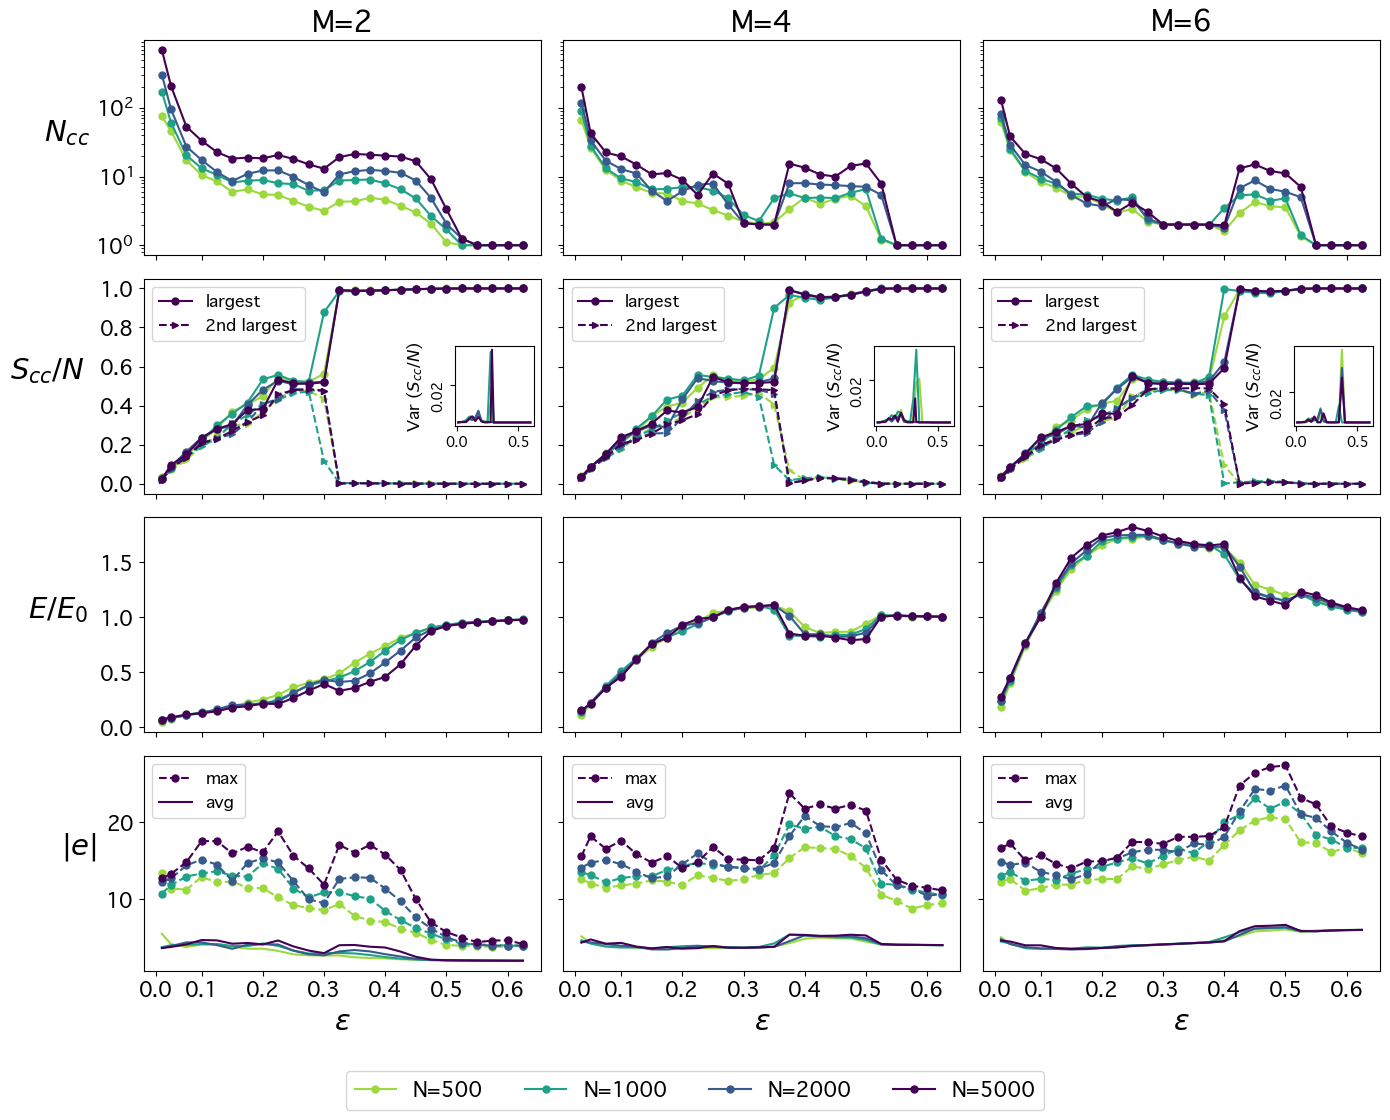

In [7]:
cond = 'max_min'
Ns = [500, 1000, 2000, 5000]
Ms = [2, 4, 6]

fig, axs = plt.subplots(4,3, sharex=True, sharey='row', figsize=figsize4x3)

for M in Ms:

    with open(f'../results/ER_{cond}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    i = Ms.index(M)
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    var_scc1 = results['var_scc1']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']
    if M==2 or M==4:
        eps_peak = results['extra_eps_N5000']
        var_peak = results['extra_var_scc1_N5000']
        
    lbls = ['largest', '2nd largest', 'avg', 'max']
    inset_ax = inset_axes(axs[1,i], width="20%", height=0.8, loc=5)
    
    for N,clr in zip(Ns, colors):
                                   
        y0 = ncc[N]
        y1 = scc1[N]
        y1_ins = var_scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[-1] else None
        la1 = lbls[1] if N==Ns[-1] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
        tk = [0.0,0.2,0.4,0.6,0.8,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        # inset plot
        x = list(epsilons)
        if (M==2 or M==4) and N==5000:
            x = sorted(x+[eps_peak])
            idx_insert = x.index(eps_peak)
            y1_ins.insert(idx_insert, var_peak)
        inset_ax.plot(x, y1_ins, color=clr)
        inset_ax.set_yticks([0.02], ['0.02'], rotation=90)
        inset_ax.set_ylabel(r'Var ($S_{cc}/N$)', fontsize=lgd_size)
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')

        la2 = lbls[2] if N==Ns[-1] else None
        la3 = lbls[3] if N==Ns[-1] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        xtck = [0.0] + list( epsilons[3::4] )
        xlbl = [str( np.round(tck,1) ) for tck in xtck]
        axs[3,i].set_xticks(xtck, xlbl)

        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)
            # show y-ticks even if shared across subplots
            #axs[j,i].yaxis.set_tick_params(which='both', labelleft=True)
    

    axs[0,i].set_title(f'M={M}', fontsize=ttl_size4x3)
    loc_leg = 2 if cond=='std' else 2
    axs[1,i].legend(fontsize=lgd_size, loc=loc_leg)
    loc_leg = 1 if cond=='std' else 2
    axs[3,i].legend(fontsize=lgd_size, loc=loc_leg)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size4x3, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size4x3, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size4x3, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size4x3, labelpad=20)

for j in range(3):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size4x3)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}.jpg', dpi=dpi)
plt.show()

# $M$-uniform ER: distributions for fixed $\epsilon$

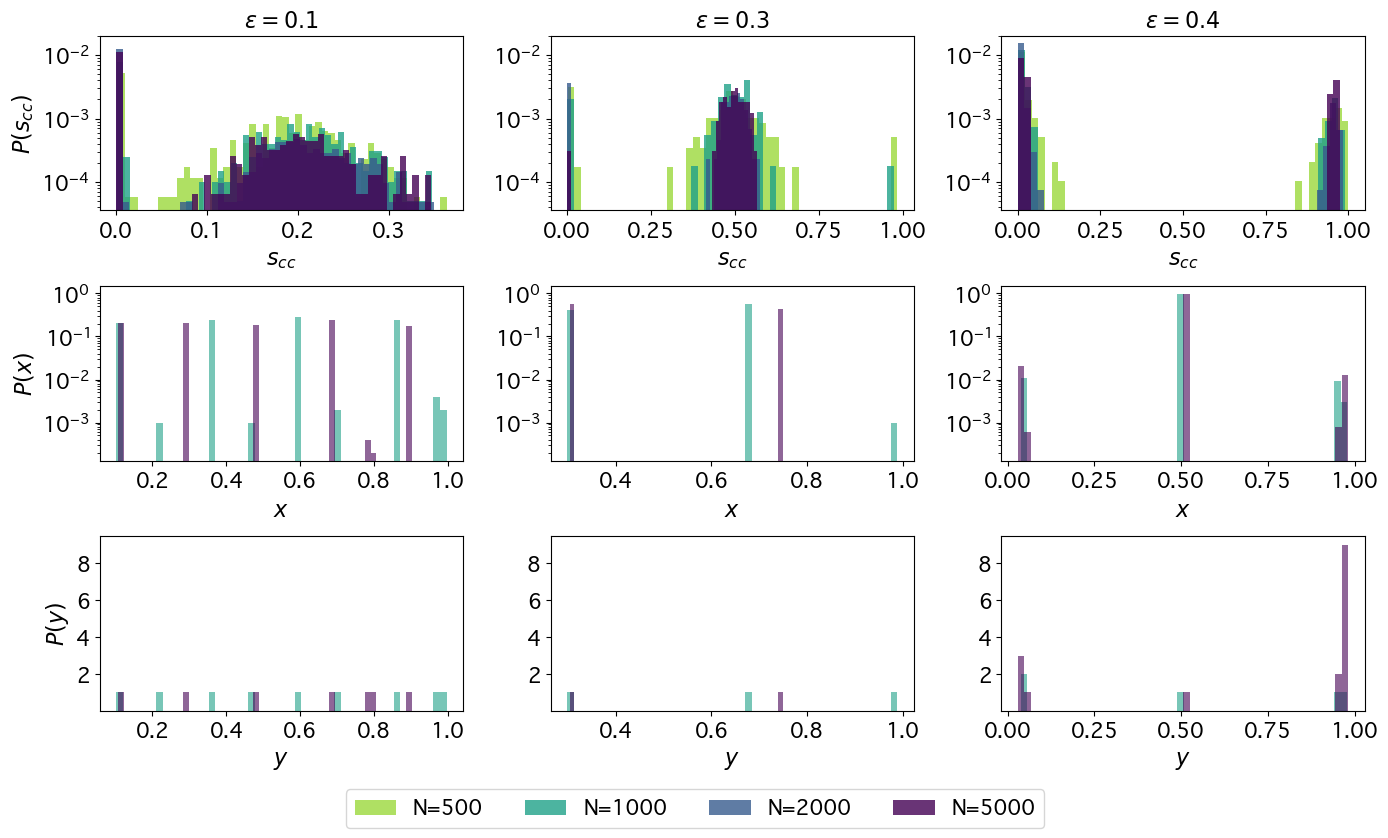

In [48]:
cond = 'max_min'
epsilons = [0.1,0.3,0.4]
M = 4
Ns = [500, 1000, 2000, 5000]


fig, axs = plt.subplots(3, 3, sharey='row', figsize=figsize3x3)

for j, eps in enumerate(epsilons):

    with open(f'../results/ER_{cond}_distrib_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
    
    sizes_cc = results['sizes_cc']
    n_iter = results['n_iter']
    op_fin = results['op_fin_1run']
    op_fin_cc = results['op_fin_cc_1run']
    
    for N,clr in zip(Ns, colors):
     
        bins_count = {np.round(j/N,3): int(sizes_cc[N][j]*n_iter) for j in sizes_cc[N].keys() }
        y0_hist = [[s]*count for s,count in bins_count.items()]
        y0_hist = [ii for jj in y0_hist for ii in jj]
        ws = [1. / (n_iter*len(y0_hist))] * len(y0_hist)
        axs[0,j].hist(y0_hist, bins=50, weights=ws, color=clr, alpha=0.8)
        axs[0,j].set_yscale('log')
        axs[0,j].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
        axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

        if N==1000 or N==5000:
            y1 = op_fin[N]
            ws = [1/N] * len(y1)
            axs[1,j].hist(y1, bins=50, weights=ws, color=clr, alpha=0.6)
            axs[1,j].set_xlabel(r'$x$', fontsize=ttl_size)
            axs[1,j].set_yscale('log')
    
            y2 = op_fin_cc[N]
            axs[2,j].hist(y2, bins=50, color=clr, alpha=0.6)
            axs[2,j].set_xlabel(r'$y$', fontsize=ttl_size)
            yticks = [2,4,6,8]
            axs[2,j].set_yticks(yticks, [str(i) for i in yticks])

        # set tick fontsize in all subplots
        for i in range(3):
            axs[i,j].tick_params(labelsize=tick_size)

    # show y-ticks even if shared across subplots
    axs[0,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[1,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[2,j].yaxis.set_tick_params(which='both', labelleft=True)

# set y-labels
axs[0,0].set_ylabel(r'$P(s_{cc})$', fontsize=ttl_size)
axs[1,0].set_ylabel(r'$P(x)$', fontsize=ttl_size)
axs[2,0].set_ylabel(r'$P(y)$', fontsize=ttl_size)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_histograms_M{M}.jpg', dpi=dpi)
plt.show()

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2766/4076452046.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,j].legend(fontsize=lgd_size)


epsilon = 0.1: k/k_0 = {500: 0.5726168825518717, 1000: 0.5916624947887428, 2000: 0.6020271658200861, 5000: 0.6115764786237304}
epsilon = 0.3: k/k_0 = {500: 1.0449379660377462, 1000: 1.0408930465187496, 2000: 1.0454225537644397, 5000: 1.0465127283031583}
epsilon = 0.4: k/k_0 = {500: 1.0820459957159128, 1000: 1.0845312615115015, 2000: 1.090605619645027, 5000: 1.0877890499058493}
epsilon = 0.6: k/k_0 = {500: 1.021013526346143, 1000: 1.021607197139789, 2000: 1.0205050991404716, 5000: 1.020878864540907}


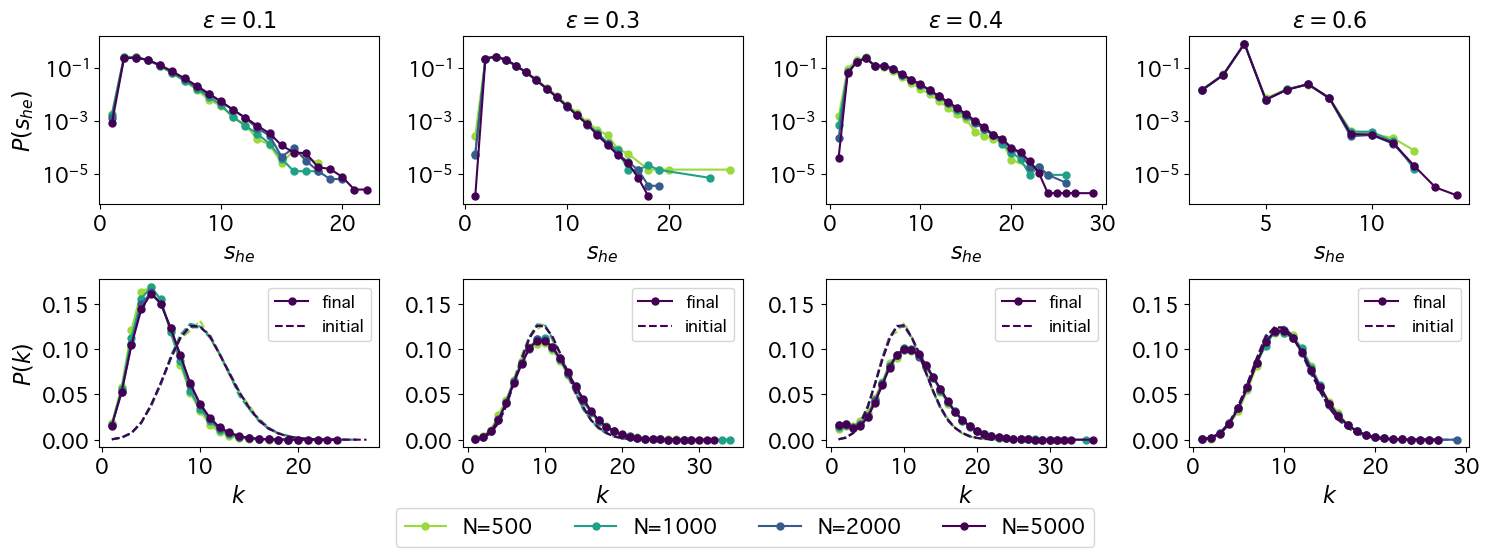

In [24]:
cond = 'max_min'
epsilons = [0.1,0.3,0.4,0.6]
M = 4
Ns = [500, 1000, 2000, 5000]


fig, axs = plt.subplots(2, len(epsilons), sharey='row', figsize=figsize2x4 )

for j, eps in enumerate(epsilons):

    with open(f'../results/ER_{cond}_distrib_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
    
    sizes_he = results['sizes_he']
    hyperdegs = results['hyperdegs']
    hyperdegs_0 = results['hyperdegs_0']
    k_ratio = results['k_ratio']
    n_iter = results['n_iter']
    
    for N,clr in zip(Ns, colors):
     
        x0 = sorted(sizes_he[N].keys())
        y0 = [sizes_he[N][x] for x in x0]
        y0_norm = [i/sum(y0) for i in y0]
        axs[0,j].plot(x0, y0_norm, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
        axs[0,j].set_yscale('log')        
        axs[0,j].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
        axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

        x1 = sorted(hyperdegs[N].keys())
        y1 = [hyperdegs[N][x] for x in x1]
        y1_norm = [i/N for i in y1]
        lab1 = 'final' if N==Ns[-1] else None
        axs[1,j].plot(x1, y1_norm, color=clr, marker='o', markersize=mrksize, label=lab1)
        axs[1,j].set_xlabel(r'$k$', fontsize=ttl_size)
        # plot also hyperdegree distribution of initial hypergraphs
        x1_0 = sorted(hyperdegs_0[N].keys())
        y1_0 = [hyperdegs_0[N][x] for x in x1_0]
        y1_0_norm = [i/N for i in y1_0]
        lab2 = 'initial' if N==Ns[-1] else None
        axs[1,j].plot(x1_0, y1_0_norm, color=clr, ls='--', label=lab2)
        axs[1,j].legend(fontsize=lgd_size)

    # set tick fontsize in all subplots
    for i in range(2):
            axs[i,j].tick_params(labelsize=tick_size)

    # show y-ticks even if shared across subplots
    axs[0,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[1,j].yaxis.set_tick_params(which='both', labelleft=True)

    print(f'epsilon = {eps}: k/k_0 = {k_ratio}')

axs[0,0].set_ylabel(r'$P(s_{he})$', fontsize=ttl_size)
axs[1,0].set_ylabel(r'$P(k)$', fontsize=ttl_size)


# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_distributions_M{M}.jpg', dpi=dpi)
plt.show()

# Temporal evolution

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2022/1809458547.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=rect_tl)


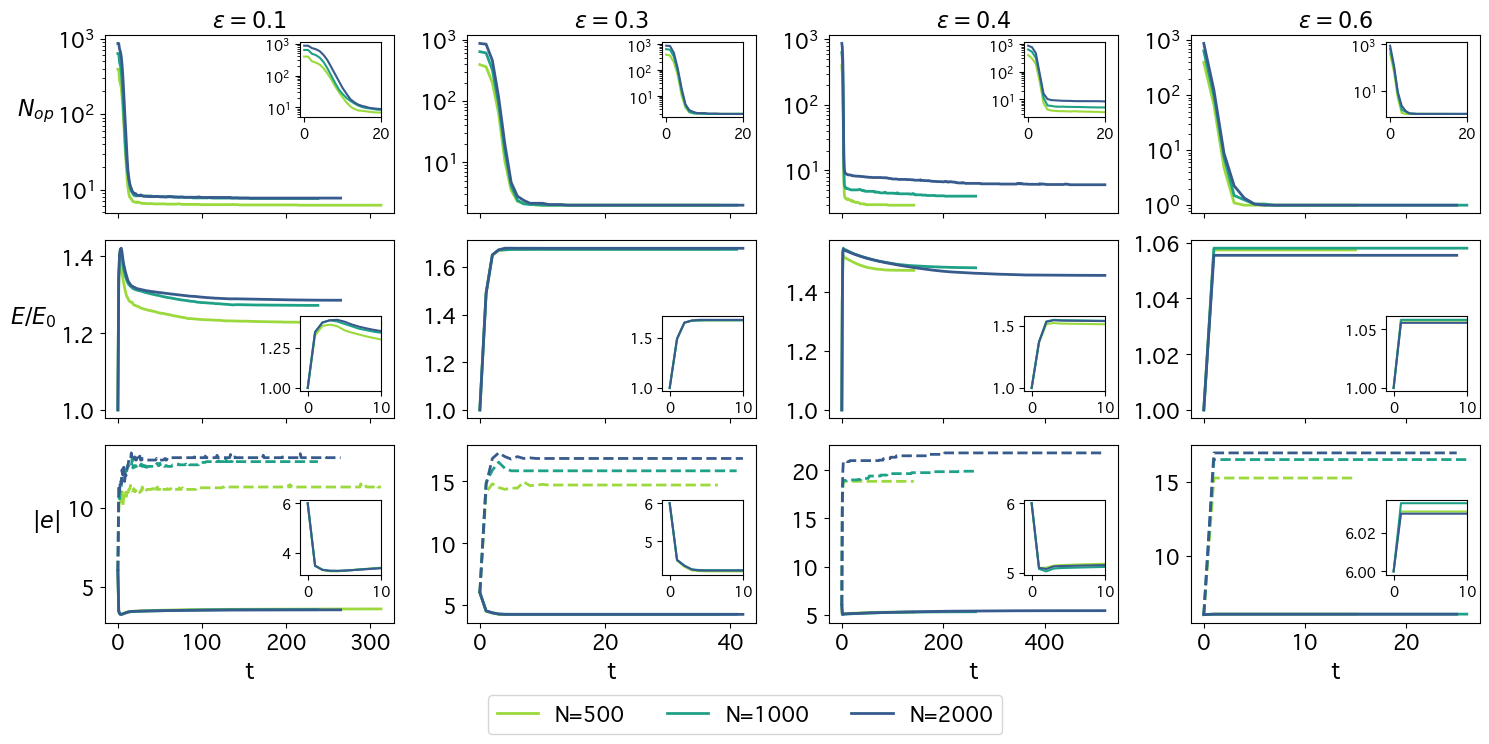

In [11]:
cond = 'max_min' 
Ns = [500, 1000, 2000]
M = 6
epsilons = [0.1, 0.3, 0.4, 0.6]

fig, axs = plt.subplots(3, len(epsilons), sharex='col', figsize=figsize3x4 )

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    
    with open(f'../results/ER_{cond}_temporal_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    inset_ax = []
    for i in range(3):
        top_ins = .53 if i==2 else .41
        if i==0 or ( M==4 and((i,j)==(1,0) or (i,j)==(1,2)) ):
            top_ins = .8
        inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.75, bbox_to_anchor=(.18, top_ins, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )

    for N, clr in zip(Ns, colors):
        nhe = results['nhe'][N]
        nop = results['nop'][N]
        s_avg = results['s_avg'][N]
        s_max = results['s_max'][N]
        s_std = results['s_std'][N]
        n_runs = results['n_iter']
        ks_avg = results['ks_avg']

        axs[0,j].plot(nop, color=clr, lw=lw, label=f'N={N}')
        axs[0,j].set_yscale('log')
        axs[0,0].set_ylabel(r'$N_{op}$', fontsize=ttl_size, rotation=0, labelpad=15)
        inset_ax[0].set_xlim(-1, 20)
        inset_ax[0].plot(nop, color=clr)
        inset_ax[0].set_yscale('log')
        
        line1, = axs[1,j].plot(nhe, color=clr, lw=lw, label=f'N={N}')
        axs[1,0].set_ylabel(r'$E/E_0$', fontsize=ttl_size, rotation=0, labelpad=20)
        inset_ax[1].set_xlim(-1, 10)
        inset_ax[1].plot(nhe, color=clr)
        
        axs[2,j].plot(s_avg, color=clr, lw=lw, label='avg')
        axs[2,j].plot(s_max, color=clr, lw=lw, linestyle='--', label='max')
        axs[2,j].set_xlabel('t', fontsize=ttl_size)
        axs[2,0].set_ylabel(r'$|e|$', fontsize=ttl_size, rotation=0, labelpad=15)
        inset_ax[2].set_xlim(-1, 10)
        inset_ax[2].plot(s_avg, color=clr)

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)
    # show y-ticks even if shared across subplots
    axs[0,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[1,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[2,j].yaxis.set_tick_params(which='both', labelleft=True)
    
    for i in range(3):
        axs[i,j].tick_params(labelsize=tick_size)

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))


# Adjust layout to make space for legend
plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_hedges.jpg', bbox_inches='tight', dpi=dpi)
plt.show()

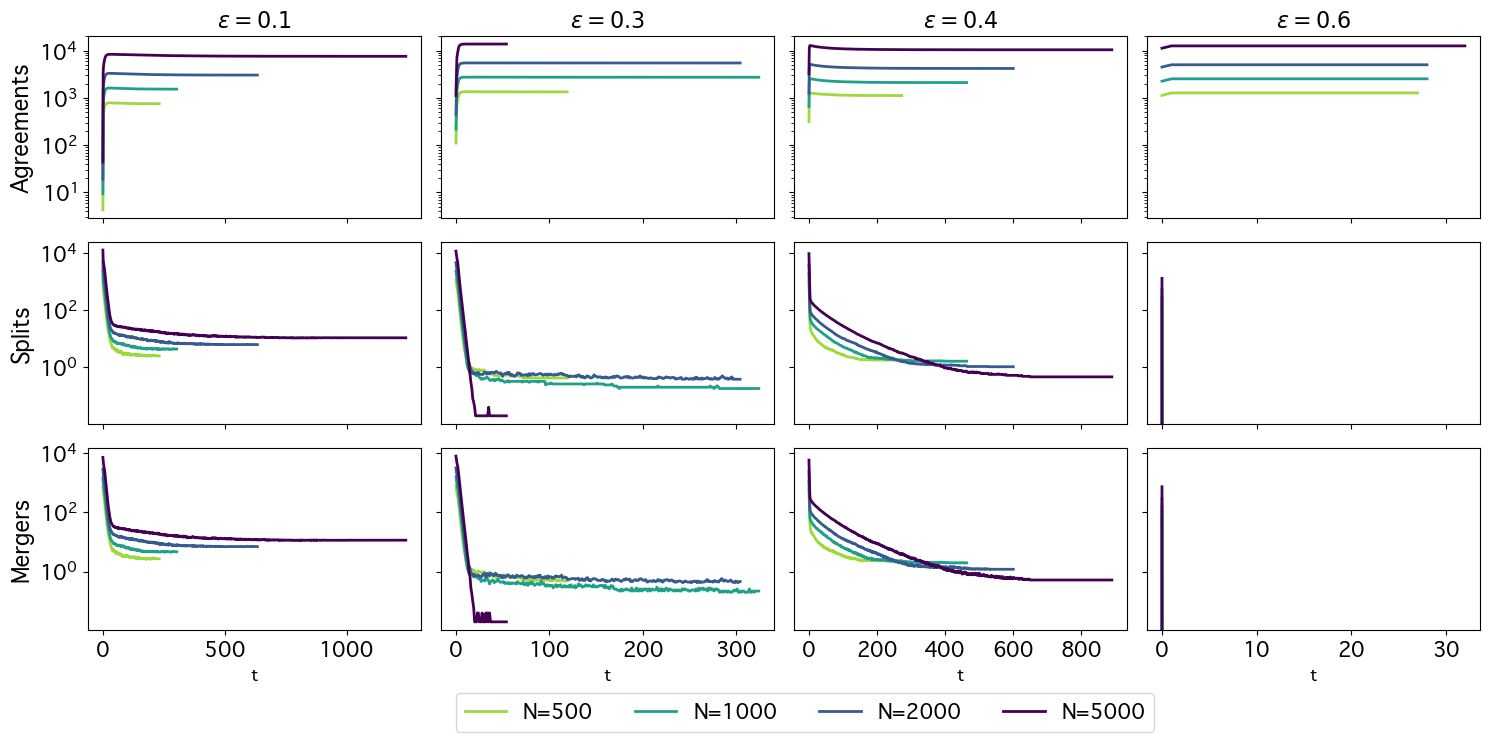

In [30]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = 4
epsilons = [0.1, 0.3, 0.4, 0.6]

fig, axs = plt.subplots(3, len(epsilons), sharex='col', sharey='row', figsize=figsize3x4)

lbl_list = ['Agreements', 'Splits', 'Mergers']
xlims = [20,10]   # for inset plots

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    with open(f'../results/ER_{cond}_temporal_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    #inset_ax = []
    #cr = [(0,0),(0,1)]
    #for i in range(3):
        #top_ins = .4 if (i,j) in cr else .75
        #inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.6, bbox_to_anchor=(.18, top_ins, .8, .2),
                   #bbox_transform=axs[i, j].transAxes) )

    for N, clr in zip(Ns, colors):
        n_agree = results['n_agree'][N]
        n_split = results['n_split'][N]
        n_merge = results['n_merge'][N]

        line1, = axs[0, j].plot(n_agree, color=clr, lw=lw, label=f'N={N}')
        #inset_ax[0].set_xlim(-1, xlims[j])
        #inset_ax[0].plot(n_agree, color=clr)

        axs[1, j].plot(n_split, color=clr, lw=lw)
        #inset_ax[1].set_xlim(-1, xlims[j])
        #inset_ax[1].plot(n_split, color=clr)

        axs[2, j].plot(n_merge, color=clr, lw=lw)
        axs[2, j].set_xlabel(r't', fontsize=lgd_size)
        #inset_ax[2].set_xlim(-1, xlims[j])
        #inset_ax[2].plot(n_merge, color=clr)       

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0, j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

    for i in range(3):
        axs[i, 0].set_ylabel(lbl_list[i], fontsize=ttl_size)
        axs[i, j].tick_params(labelsize=tick_size)
        axs[i, j].set_yscale('log')
        #inset_ax[i].set_yscale('log')

# Adjust layout to make space for legend
plt.tight_layout(rect=rect_tl)

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=(0.54, 0.005), fontsize=tick_size, ncol=len(Ns))

plt.savefig(f'../figures/ER_M{M}_{cond}_temporal_n_events.jpg', dpi=dpi)
plt.show()

# Non-uniform ER - steady state vs $\epsilon$

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2225/983394598.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(fontsize=lgd_size, loc=5)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2225/983394598.py:56: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1,1].legend(fontsize=lgd_size)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2225/983394598.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[0,1].legend(fontsize=lgd_size, loc=5)
/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_2225/983394598.py:56: UserWarning: No artists with labels found

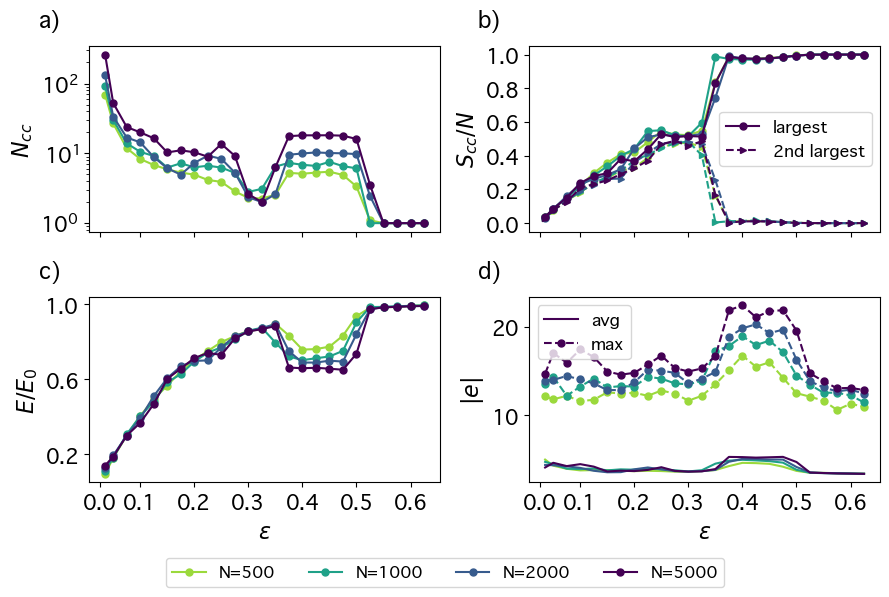

In [36]:
s_str = '246'
cond = 'max_min'

with open(f'../results/ER_{cond}_M{s_str}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

Ns = [500, 1000, 2000, 5000]
fig, axs = plt.subplots(2,2, sharex=True, figsize=figsize2x2)

for N,clr in zip(Ns, colors):

    y0 = ncc[N]
    y1 = scc1[N]
    y2 = scc2[N]
    y3 = nhe[N]
    y4 = s_avg[N]
    y5 = s_max[N]

    line1, = axs[0,0].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    legend_handles.append(line1)
    legend_labels.append(f'N={N}')
    axs[0,0].set_yscale('log')
    axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

    la0 = lbls[0] if N==Ns[-1] else None
    la1 = lbls[1] if N==Ns[-1] else None
    axs[0,1].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
    axs[0,1].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
    tk = [0.0,0.2,0.4,0.6,0.8,1.0]
    axs[0,1].set_yticks(tk, [str(i) for i in tk])
    axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    axs[0,1].legend(fontsize=lgd_size, loc=5)
        
    axs[1,0].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
    axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)
    axs[1,0].set_yticks([0.2,0.6,1.0])

    la2 = lbls[2] if N==Ns[-1] else None
    la3 = lbls[3] if N==Ns[-1] else None
    axs[1,1].plot(epsilons, y4, label=la2, color=clr)
    axs[1,1].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
    axs[1,1].set_ylabel(r'$|e|$', fontsize=ttl_size)
    axs[1,1].legend(fontsize=lgd_size)

# set xlabel tick fontsize in all subplots
for j in range(2):
    axs[1,j].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    xtck = [0.0] + list( epsilons[3::4] )
    xlbl = [str( np.round(tck,1) ) for tck in xtck]
    axs[1,j].set_xticks(xtck, xlbl)
    for i in range(2):
        axs[i,j].tick_params(labelsize=tick_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=lgd_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_M{s_str}.jpg', dpi=dpi)
plt.show()

# SocioPatterns hypergraph

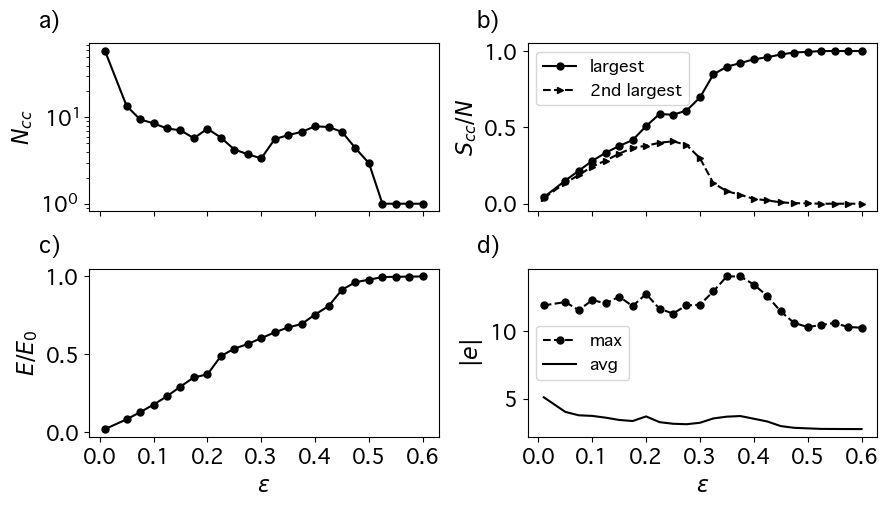

In [39]:
tag = 'SFHH'
cond = 'max_min'
with open(f'../results/SP_{tag}_{cond}.pkl', 'rb') as f:
    res = pickle.load(f)

epsilons = res['epsilons']
ncc = res['ncc']
scc1 = res['scc1']
scc2 = res['scc2']
nhe = res['nhe']
s_avg = res['s_avg']
s_max = res['s_max']

lbls = ['largest', '2nd largest', 'avg', 'max']
clr = 'black'

fig, axs = plt.subplots(2,2, sharex=True, figsize=(figsize2x2[0],figsize2x2[1]*0.8))

axs[0,0].plot(epsilons, ncc, marker='o', markersize=mrksize, color=clr)
axs[0,0].set_yscale('log')
axs[0,0].set_ylabel(r'$N_{cc}$', fontsize=ttl_size)

axs[0,1].plot(epsilons, scc1, linestyle='-', marker='o', markersize=mrksize, label=lbls[0], color=clr)
axs[0,1].plot(epsilons, scc2, linestyle='--', marker='>', markersize=mrksize, label=lbls[1], color=clr)
axs[0,1].legend(fontsize=lgd_size)
axs[0,1].set_ylabel(r'$S_{cc} / N$', fontsize=ttl_size)
    
axs[1,0].plot(epsilons, nhe, marker='o', markersize=mrksize, color=clr)
axs[1,0].set_ylabel(r'$E / E_0$', fontsize=ttl_size)

axs[1,1].plot(epsilons, s_max, label=lbls[3], linestyle='--', marker='o', markersize=mrksize, color=clr)
axs[1,1].plot(epsilons, s_avg, label=lbls[2], color=clr)
axs[1,1].legend(fontsize=lgd_size, loc=6)
axs[1,1].set_ylabel(r'$|e|$', fontsize=ttl_size)

# set xlabel tick fontsize in all subplots
for i in range(2):
    axs[1,i].set_xlabel(r'$\epsilon$', fontsize=ttl_size)
    xtck = [0.0] + list( epsilons[3::4] )
    xlbl = [str( np.round(tck,1) ) for tck in xtck]
    axs[1,i].set_xticks(xtck, xlbl)
    for j in range(2):
        axs[i,j].tick_params(labelsize=tick_size)

# Add subplot labels
lbls = ['a)','b)','c)','d)']
for (i,j),lbl in zip(product([0,1],[0,1]), lbls):
    axs[i,j].text(-0.08, 1.2, lbl, transform=axs[i,j].transAxes, 
                  fontsize=ttl_size, fontweight='bold', va='top', ha='right')

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}.jpg', dpi=dpi)
plt.show()

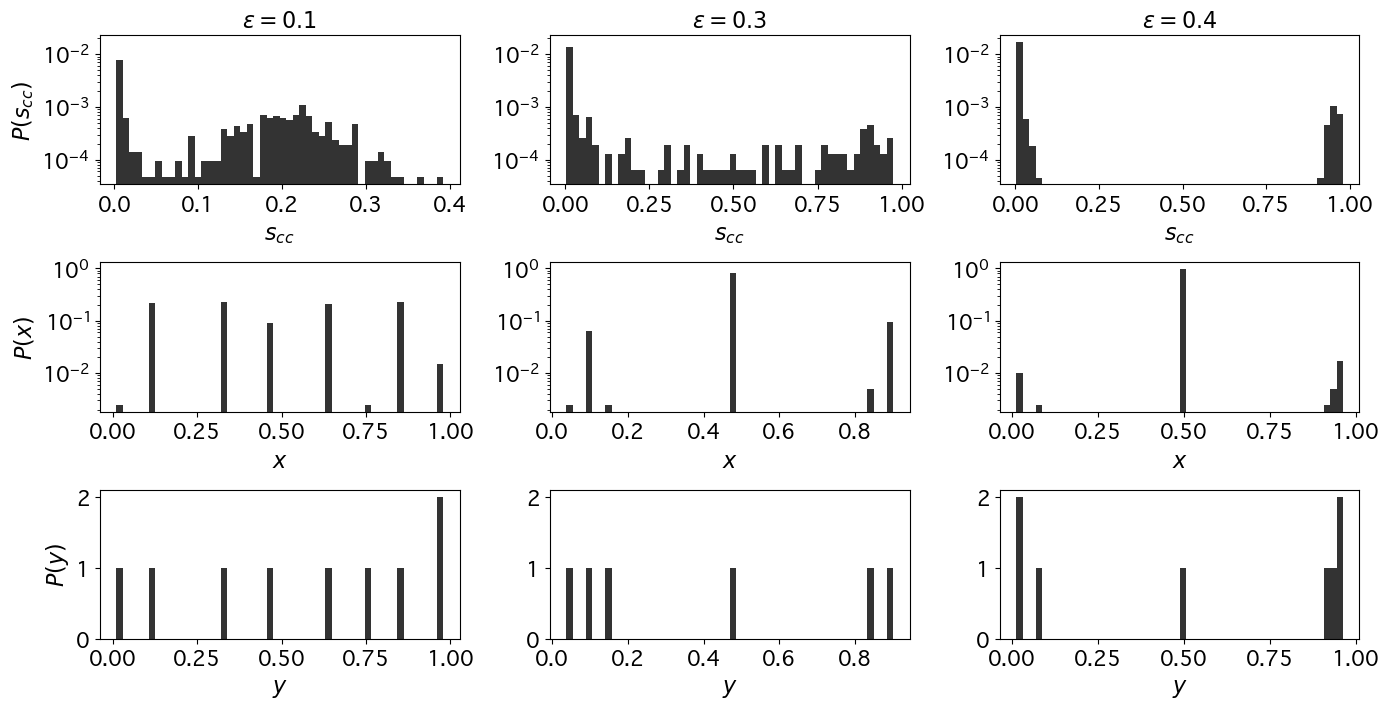

In [56]:
cond = 'max_min'
epsilons = [0.1,0.3,0.4]

tag = 'SFHH'
cond = 'max_min'
clr = 'black'

fig, axs = plt.subplots(3, 3, sharey='row', figsize=(figsize3x3[0],figsize3x3[1]*0.8))

for j, eps in enumerate(epsilons):

    with open(f'../results/SP_{tag}_{cond}_distrib_eps_{eps}.pkl', 'rb') as f:
        results = pickle.load(f)
    
    sizes_cc = results['sizes_cc']
    n_iter = results['n_iter']
    op_fin = results['op_fin_1run']
    op_fin_cc = results['op_fin_cc_1run']
    N=len(op_fin)

    bins_count = {np.round(j/N,3): int(sizes_cc[j]*n_iter) for j in sizes_cc.keys() }
    y0_hist = [[s]*count for s,count in bins_count.items()]
    y0_hist = [ii for jj in y0_hist for ii in jj]
    ws = [1. / (n_iter*len(y0_hist))] * len(y0_hist)
    axs[0,j].hist(y0_hist, bins=50, weights=ws, color=clr, alpha=0.8)
    axs[0,j].set_yscale('log')
    axs[0,j].set_xlabel(r'$s_{cc}$', fontsize=ttl_size)
    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

    y1 = op_fin
    ws = [1/N] * len(y1)
    axs[1,j].hist(y1, bins=50, weights=ws, color=clr, alpha=0.8)
    axs[1,j].set_xlabel(r'$x$', fontsize=ttl_size)
    axs[1,j].set_yscale('log')

    axs[2,j].hist(op_fin_cc, bins=50, color=clr, alpha=0.8)
    axs[2,j].set_xlabel(r'$y$', fontsize=ttl_size)

    # set tick fontsize in all subplots
    for i in range(3):
            axs[i,j].tick_params(labelsize=tick_size)
            # show y-ticks even if shared across subplots
            axs[i,j].yaxis.set_tick_params(which='both', labelleft=True)

# set y-labels
axs[0,0].set_ylabel(r'$P(s_{cc})$', fontsize=ttl_size)
axs[1,0].set_ylabel(r'$P(x)$', fontsize=ttl_size)
axs[2,0].set_ylabel(r'$P(y)$', fontsize=ttl_size)

plt.tight_layout()
plt.savefig(f'../figures/SP_{tag}_{cond}_histograms.jpg', dpi=dpi)
plt.show()

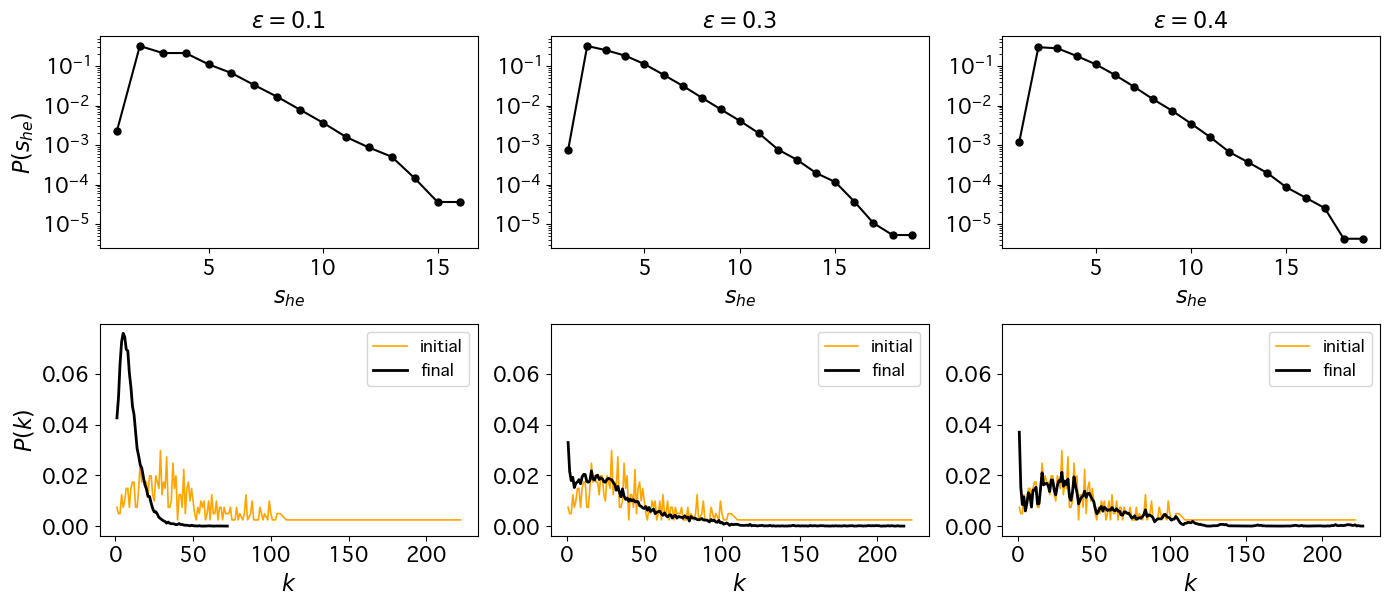

In [42]:
cond = 'max_min'
epsilons = [0.1,0.3,0.4]

tag = 'SFHH'
cond = 'max_min'
clr = 'black'


fig, axs = plt.subplots(2, 3, sharey='row', figsize=figsize2x3)

for j, eps in enumerate(epsilons):

    with open(f'../results/SP_{tag}_{cond}_distrib_eps_{eps}.pkl', 'rb') as f:
        results = pickle.load(f)
    
    sizes_he = results['sizes_he']
    hyperdegs = results['hyperdegs']
    hyperdegs_0 = results['hyperdegs_0']
    op_fin = results['op_fin_1run']
    N=len(op_fin)

    x0 = sorted(sizes_he.keys())
    y0 = [sizes_he[x] for x in x0]
    y0_norm = [i/sum(y0) for i in y0]
    axs[0,j].plot(x0, y0_norm, color=clr, marker='o', markersize=mrksize)
    axs[0,j].set_yscale('log')        
    axs[0,j].set_xlabel(r'$s_{he}$', fontsize=ttl_size)
    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)

    # plot hyperdegree distribution of initial hypergraphs
    x1_0 = sorted(hyperdegs_0.keys())
    y1_0 = [hyperdegs_0[x] for x in x1_0]
    y1_0_norm = [i/N for i in y1_0]
    axs[1,j].plot(x1_0, y1_0_norm, color='orange', lw=1.2, label='initial')
    
    x1 = sorted(hyperdegs.keys())
    y1 = [hyperdegs[x] for x in x1]
    y1_norm = [i/N for i in y1]
    axs[1,j].plot(x1, y1_norm, color=clr, lw=2, label='final')
    axs[1,j].set_xlabel(r'$k$', fontsize=ttl_size)
    axs[1,j].legend(fontsize=lgd_size)

    # set tick fontsize in all subplots
    for i in range(2):
            axs[i,j].tick_params(labelsize=tick_size)
            # show y-ticks even if shared across subplots
            axs[i,j].yaxis.set_tick_params(which='both', labelleft=True)
        

axs[0,0].set_ylabel(r'$P(s_{he})$', fontsize=ttl_size)
axs[1,0].set_ylabel(r'$P(k)$', fontsize=ttl_size)


plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/SP_{tag}_{cond}_distributions.jpg', dpi=dpi)
plt.show()

# Bimodal distribution of initial opinions

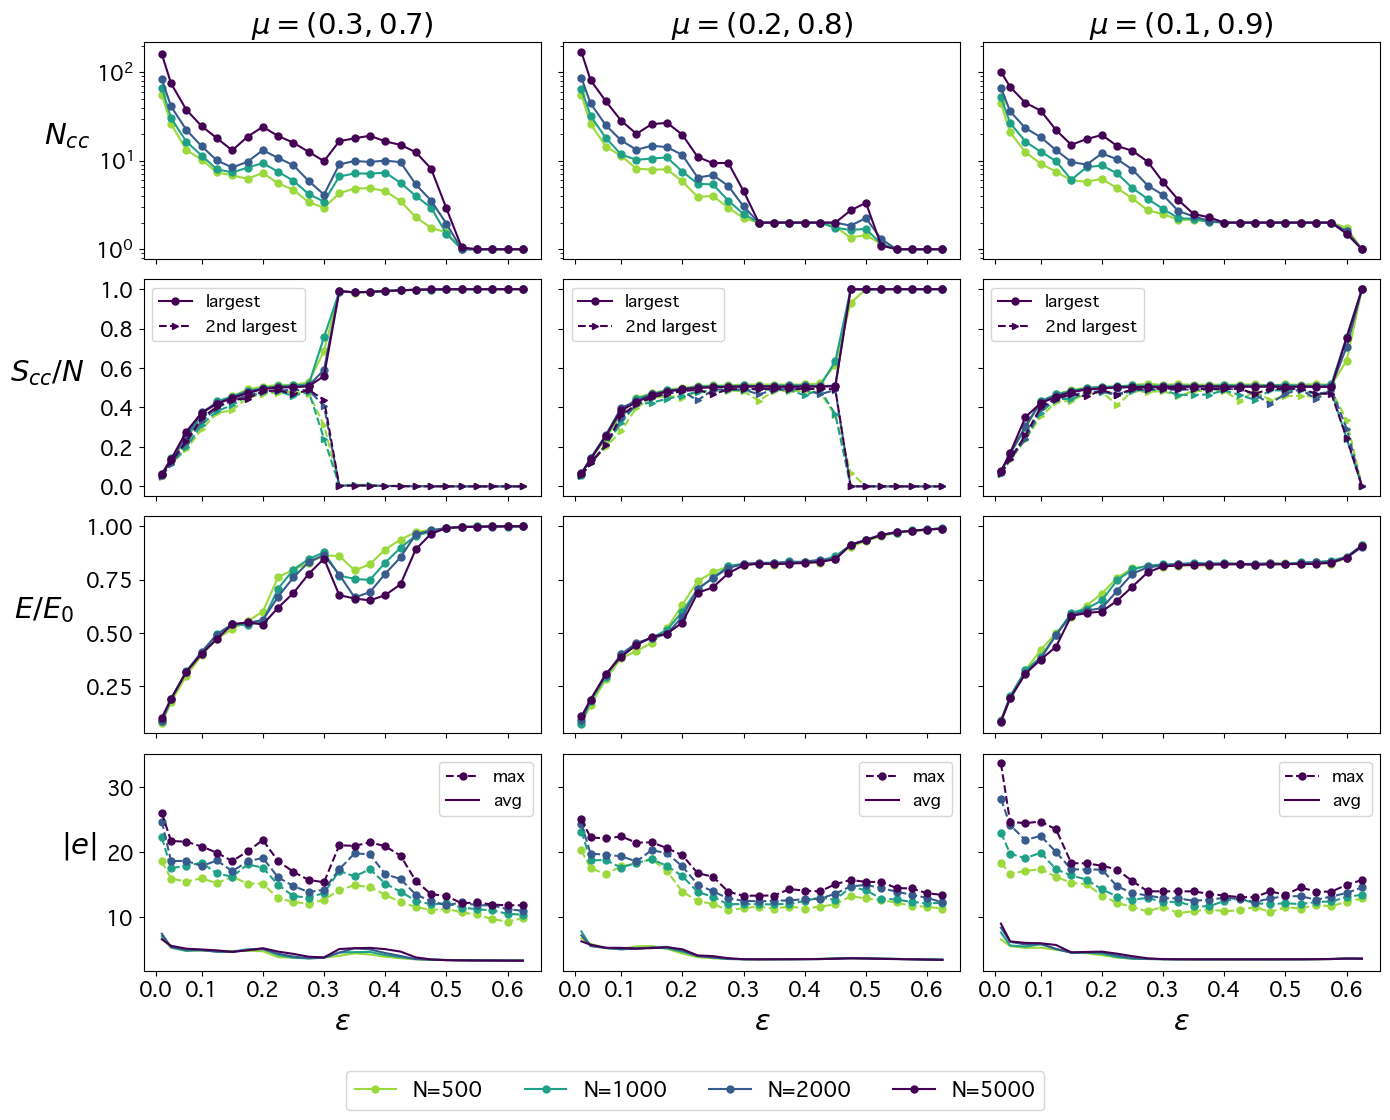

In [48]:
cond = 'max_min' 
Ns = [500, 1000, 2000, 5000]
M = '246'
means_list = [[0.3,0.7], [0.2,0.8], [0.1,0.9]]

fig, axs = plt.subplots(4,3, sharex=True, sharey='row', figsize=figsize4x3)

for means in means_list:
    
    i = means_list.index(means)
    with open(f'../results/ER_{cond}_bimodal_{means[0]}_{means[1]}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)
        
    epsilons = results['epsilons']
    ncc = results['ncc']
    scc1 = results['scc1']
    scc2 = results['scc2']
    nhe = results['nhe']
    s_avg = results['s_avg']
    s_max = results['s_max']

    lbls = ['largest', '2nd largest', 'avg', 'max']
    for N,clr in zip(Ns, colors):
                                   
        y0 = ncc[N]
        y1 = scc1[N]
        y2 = scc2[N]
        y3 = nhe[N]
        y4 = s_avg[N]
        y5 = s_max[N]
        
        axs[0,i].plot(epsilons, y0, color=clr, marker='o', markersize=mrksize, label=f'N={N}')
        axs[0,i].set_yscale('log')

        la0 = lbls[0] if N==Ns[-1] else None
        la1 = lbls[1] if N==Ns[-1] else None
        axs[1,i].plot(epsilons, y1, color=clr, linestyle='-', marker='o', markersize=mrksize, label=la0)
        axs[1,i].plot(epsilons, y2, color=clr, linestyle='--', marker='>', markersize=mrksize, label=la1)
        tk = [0.0,0.2,0.4,0.6,0.8,1.0]
        axs[1,i].set_yticks(tk, [str(i) for i in tk])
        
        axs[2,i].plot(epsilons, y3, color=clr, marker='o', markersize=mrksize, label=f'N={N}')

        la2 = lbls[2] if N==Ns[-1] else None
        la3 = lbls[3] if N==Ns[-1] else None
        axs[3,i].plot(epsilons, y5, label=la3, linestyle='--', marker='o', markersize=mrksize, color=clr)
        axs[3,i].plot(epsilons, y4, label=la2, color=clr)
        xtck = [0.0] + list( epsilons[3::4] )
        xlbl = [str( np.round(tck,1) ) for tck in xtck]
        axs[3,i].set_xticks(xtck, xlbl)
        # set tick fontsize in all subplots
        for j in range(4):
            axs[j,i].tick_params(labelsize=tick_size)

    axs[0,i].set_title(fr'$\mu=({means[0]},{means[1]})$', fontsize=ttl_size4x3)
    axs[1,i].legend(fontsize=lgd_size, loc=2)
    axs[3,i].legend(fontsize=lgd_size)

axs[0,0].set_ylabel(r'$N_{cc}$', rotation=0, fontsize=ttl_size4x3, labelpad=20)
axs[1,0].set_ylabel(r'$S_{cc}/N$', rotation=0, fontsize=ttl_size4x3, labelpad=38)
axs[2,0].set_ylabel(r'$E/E_0$', rotation=0, fontsize=ttl_size4x3, labelpad=30)
axs[3,0].set_ylabel(r'$|e|$', rotation=0, fontsize=ttl_size4x3, labelpad=20)

for j in range(3):
    axs[-1, j].set_xlabel(r'$\epsilon$', fontsize=ttl_size4x3)

# Global legend below plot, centered
legend_labels = [f'N={N}' for N in Ns]
fig.legend(labels=legend_labels, loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))

plt.tight_layout(rect=rect_tl)
plt.savefig(f'../figures/ER_{cond}_bimodal_M{M}.jpg', dpi=dpi)
plt.show()

# Temporal evolution for M=6

/var/folders/tj/g17csjt912n77jd7klwd63s00000gn/T/ipykernel_1618/3875335671.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=rect_tl)


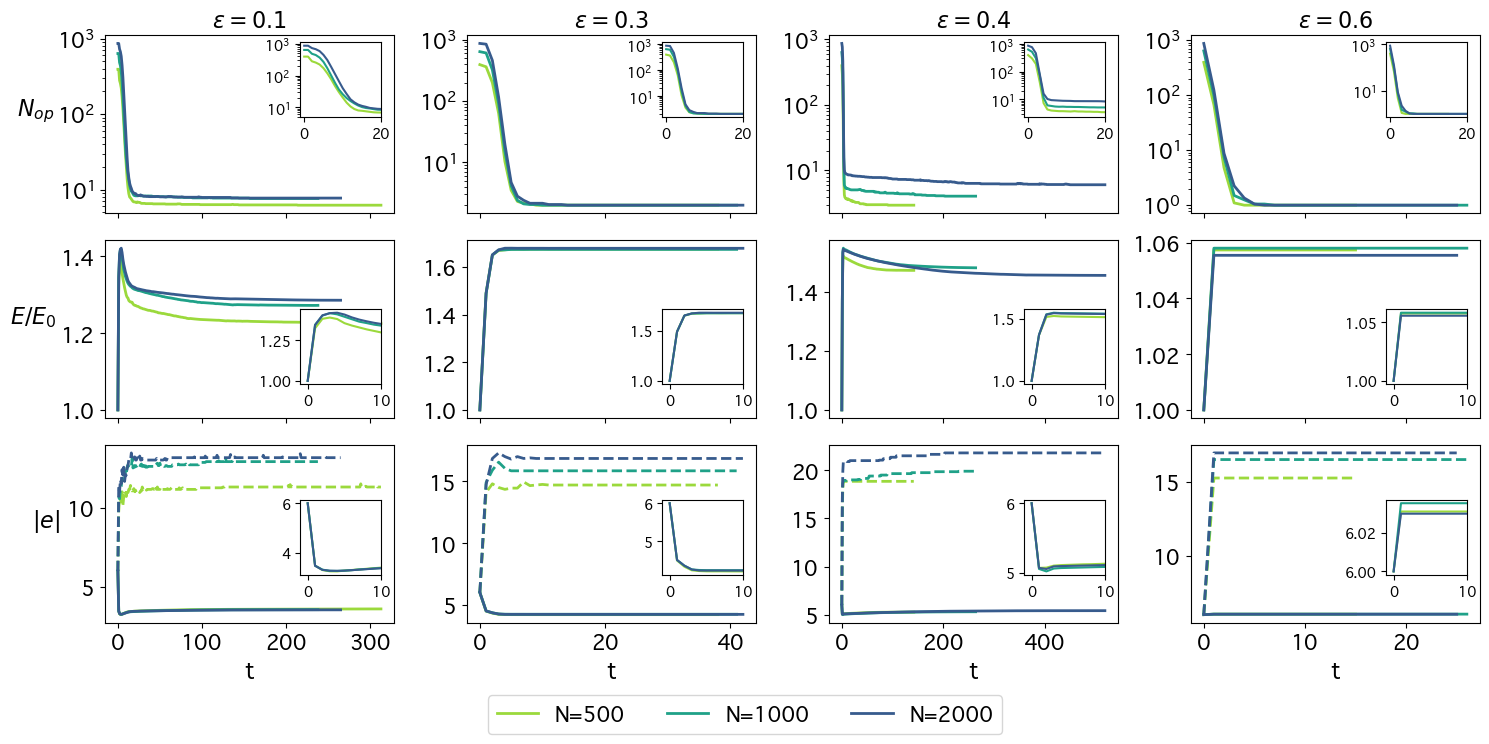

In [20]:
cond = 'max_min' 
Ns = [500, 1000, 2000]
M = 6
epsilons = [0.1, 0.3, 0.4, 0.6]

fig, axs = plt.subplots(3, len(epsilons), sharex='col', figsize=figsize3x4 )

# collect handles/labels for a global legend
legend_handles = []
legend_labels = []

for j, eps in enumerate(epsilons):
    
    with open(f'../results/ER_{cond}_temporal_eps_{eps}_M{M}.pkl', 'rb') as f:
        results = pickle.load(f)

    inset_ax = []
    for i in range(3):
        top_ins = .53 if i==2 else .45
        if i==0:
            top_ins = .8
        inset_ax.append( inset_axes(axs[i, j], width="35%", height=0.75, bbox_to_anchor=(.18, top_ins, .8, .2),
                   bbox_transform=axs[i, j].transAxes) )

    for N, clr in zip(Ns, colors):
        nhe = results['nhe'][N]
        nop = results['nop'][N]
        s_avg = results['s_avg'][N]
        s_max = results['s_max'][N]
        s_std = results['s_std'][N]
        n_runs = results['n_iter']
        ks_avg = results['ks_avg']

        axs[0,j].plot(nop, color=clr, lw=lw, label=f'N={N}')
        axs[0,j].set_yscale('log')
        axs[0,0].set_ylabel(r'$N_{op}$', fontsize=ttl_size, rotation=0, labelpad=15)
        inset_ax[0].set_xlim(-1, 20)
        inset_ax[0].plot(nop, color=clr)
        inset_ax[0].set_yscale('log')
        
        line1, = axs[1,j].plot(nhe, color=clr, lw=lw, label=f'N={N}')
        axs[1,0].set_ylabel(r'$E/E_0$', fontsize=ttl_size, rotation=0, labelpad=20)
        inset_ax[1].set_xlim(-1, 10)
        inset_ax[1].plot(nhe, color=clr)
        
        axs[2,j].plot(s_avg, color=clr, lw=lw, label='avg')
        axs[2,j].plot(s_max, color=clr, lw=lw, linestyle='--', label='max')
        axs[2,j].set_xlabel('t', fontsize=ttl_size)
        axs[2,0].set_ylabel(r'$|e|$', fontsize=ttl_size, rotation=0, labelpad=15)
        inset_ax[2].set_xlim(-1, 10)
        inset_ax[2].plot(s_avg, color=clr)

        # Save one set of handles/labels (only from first subplot)
        if j == 0:
            legend_handles.append(line1)
            legend_labels.append(f'N={N}')

    axs[0,j].set_title(rf'$\epsilon = {eps}$', fontsize=ttl_size)
    # show y-ticks even if shared across subplots
    axs[0,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[1,j].yaxis.set_tick_params(which='both', labelleft=True)
    axs[2,j].yaxis.set_tick_params(which='both', labelleft=True)
    
    for i in range(3):
        axs[i,j].tick_params(labelsize=tick_size)

# Global legend below plot, centered
fig.legend(handles=legend_handles, labels=legend_labels,
           loc='lower center', bbox_to_anchor=bbox_legend, fontsize=tick_size, ncol=len(Ns))


# Adjust layout to make space for legend
plt.tight_layout(rect=rect_tl)
plt.show()

# Additional checks

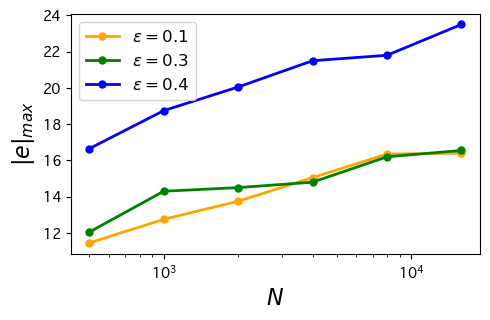

In [13]:
cond = 'max_min'
M = 4

with open(f'../results/ER_{cond}_e_max_M{M}.pkl', 'rb') as f:
    results_em = pickle.load(f)

epsilons = [0.1, 0.3, 0.4]
clrs = ['orange', 'green', 'blue']

plt.figure(figsize=(5,3.3))

for eps,clr in zip(epsilons, clrs):
    x2 = results_em[eps]['Ns']
    y2 = results_em[eps]['e_max']
    plt.plot(x2, y2, color=clr, marker='o', markersize=mrksize, lw=lw, label=fr'$\epsilon = {eps}$')
    plt.xscale('log')
    plt.ylabel(r'$|e|_{max}$', fontsize=ttl_size)
    plt.xlabel(r'$N$', fontsize=ttl_size)
    plt.legend(fontsize=lgd_size)

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_e_max_M{M}.jpg', dpi=dpi)
plt.show()

epsilon=0.4, N=1000 - Pearson correlation: 0.8557691622651813 p_value: 6.810963574204552e-288 

epsilon=0.4, N=5000 - Pearson correlation: 0.8479733502512675 p_value: 0.0 



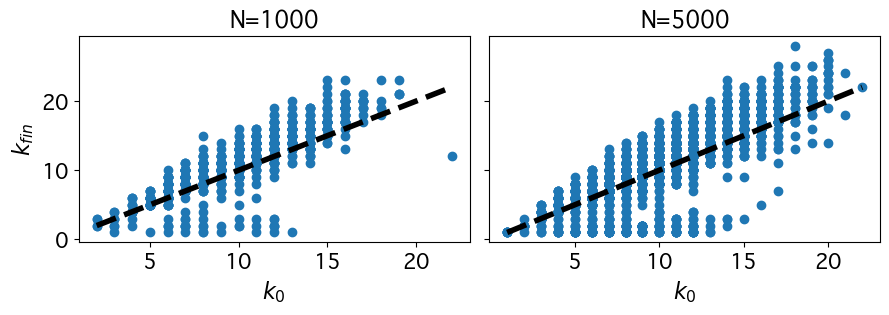

In [44]:
from scipy.stats import pearsonr

cond = 'max_min'
M = 4

with open(f'../results/ER_{cond}_hdegs_M{M}.pkl', 'rb') as f:
    res = pickle.load(f)

k0_k_N = res['k0_k_N']
epsilon = res['epsilon']
Ns = list(k0_k_N.keys())

fig, axs = plt.subplots(1, 2, sharey='row', figsize=(figsize2x2[0],figsize2x2[1]*0.5) )

for i,N in enumerate(Ns):

    k0 = k0_k_N[N][0]
    k_fin = k0_k_N[N][1]
    
    axs[i].plot([min(k0),max(k0)], [min(k0),max(k0)], ls='--', lw=4, color='black')
    axs[i].scatter(k0, k_fin, linewidths=1)
    axs[i].set_title(f'N={N}', fontsize=ttl_size)
    xticks = [5,10,15,20]
    axs[i].set_xticks(xticks, [str(i) for i in xticks])
    axs[i].tick_params(labelsize=tick_size)

    r, p_value = pearsonr(k0, k_fin)
    print(f'epsilon={epsilon}, N={N} - Pearson correlation:', r, 'p_value:', p_value, '\n')

axs[0].set_ylabel(r'$k_{fin}$', fontsize=ttl_size)
axs[0].set_xlabel(r'$k_0$', fontsize=ttl_size)
axs[1].set_xlabel(r'$k_0$', fontsize=ttl_size)

plt.tight_layout()
plt.savefig(f'../figures/ER_{cond}_hdegs_M{M}.jpg', dpi=dpi)
plt.show()